# Four-frequency FBTDCA training — 1.5-second stimulus

Train a separate subject-specific model for a 1.5-second visual stimulus. The first 0.25 seconds are excluded, so the classifier uses the `0.25–1.50 s` interval: 1.25 seconds, represented by 312 samples at 250 Hz.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from ssvep_bci.training import load_fbtdca_dataset, save_fbtdca_model, train_fbtdca

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "ssvep-bci" / "pyproject.toml").is_file():
            return candidate
        if (candidate / "src" / "ssvep_bci").is_dir():
            return candidate.parent
    raise FileNotFoundError("Could not locate the BCI repository root")

REPO_ROOT = find_repo_root()
PARTICIPANT_ID = "mike_a"
STIMULATION_SECONDS = 1.5
WINDOW_ONSET_OFFSET_SECONDS = 0.25
WINDOW_LENGTH_SECONDS = STIMULATION_SECONDS - WINDOW_ONSET_OFFSET_SECONDS
SESSION_PATHS = [
    REPO_ROOT / "ssvep-bci/sessions/20260801T192258Z_mike_a_fbtdca-run-1_a299483b",
    REPO_ROOT / "ssvep-bci/sessions/20260801T193028Z_mike_a_fbtdca-run-2_f940ff62",
]
MODEL_PATH = REPO_ROOT / "ssvep-bci/models/mike_a/four_frequency_fbtdca_1p5s_stimulus.joblib"

## Extract the final 1.25 seconds of each 1.5-second interval

In [2]:
missing_paths = [path for path in SESSION_PATHS if not path.is_dir()]
if missing_paths:
    raise FileNotFoundError(f"Missing configured session folders: {missing_paths}")
dataset = load_fbtdca_dataset(
    SESSION_PATHS,
    PARTICIPANT_ID,
    window_onset_offset_seconds=WINDOW_ONSET_OFFSET_SECONDS,
    window_length_seconds=WINDOW_LENGTH_SECONDS,
)
print("Sessions:", len(dataset.session_paths))
print("EEG shape (trials, channels, samples):", dataset.eeg.shape)
print("Window:", dataset.window_onset_offset_seconds, "to",
      dataset.window_onset_offset_seconds + dataset.window_length_seconds, "seconds")
print("Frequencies:", dataset.candidate_frequencies_hz)
print("Excluded incomplete trials:", len(dataset.excluded_trials))
print("Trials per class:", np.bincount(dataset.labels, minlength=4))

Sessions: 2
EEG shape (trials, channels, samples): (96, 8, 312)
Window: 0.25 to 1.5 seconds
Frequencies: (8.0, 9.0, 13.0, 14.0)
Excluded incomplete trials: 0
Trials per class: [24 24 24 24]


## Leave-one-session-out validation and final fit

In [3]:
estimator, validation = train_fbtdca(dataset)
for fold in validation["folds"]:
    print(f"{fold['held_out_session_id']}: balanced accuracy {fold['balanced_accuracy']:.3f}")
print(f"Overall accuracy: {validation['accuracy']:.3f}")
print(f"Overall balanced accuracy: {validation['balanced_accuracy']:.3f}")

a299483b-4715-4168-99be-cbdf9d6f5dc0: balanced accuracy 0.750
f940ff62-e339-49c0-9c9c-29293f19e9b8: balanced accuracy 0.875
Overall accuracy: 0.812
Overall balanced accuracy: 0.812


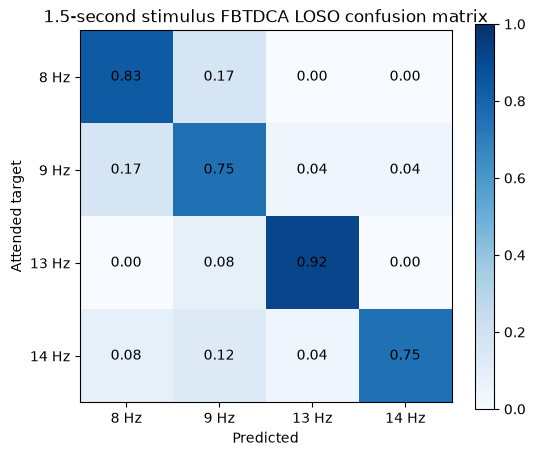

In [4]:
matrix = np.asarray(validation["normalized_confusion_matrix"])
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1)
labels = [f"{value:g} Hz" for value in dataset.candidate_frequencies_hz]
ax.set(xticks=range(4), yticks=range(4), xticklabels=labels, yticklabels=labels,
       xlabel="Predicted", ylabel="Attended target",
       title="1.5-second stimulus FBTDCA LOSO confusion matrix")
for row in range(4):
    for column in range(4):
        ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax)
plt.show()

## Save the separate 1.5-second-stimulus model

In [5]:
saved_model, saved_summary = save_fbtdca_model(
    dataset, estimator, validation, MODEL_PATH
)
print("Saved model:", saved_model)
print("Saved summary:", saved_summary)

Saved model: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\models\mike_a\four_frequency_fbtdca_1p5s_stimulus.joblib
Saved summary: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\models\mike_a\four_frequency_fbtdca_1p5s_stimulus_summary.json
